### LH DataFrame
**Populations of Lynx and Hare observed in Hudson Bay between 1845 and 1874**  
- The first column *year* represents the time points in years.  
- The second column *hares* contains the number of Hares observed.  
- The third column *lynx* contains the number of Lynx observed.  

### COVID-19 DataFrame
**New COVID-19 infections per day during the first wave in Germany**  
- The first column *day* represents the time points in days.  
- The second column *new_infections* provides the number of new infections reported for each day.  




In [9]:
import jax.numpy as jnp
import pandas as pd

# Load JAX arrays
lh_data = jnp.load("LH_data.npy")
covid_data = jnp.load("covid_data.npy")

# Make LH DataFrame
lh_df = pd.DataFrame({
    "Year": lh_data[:, 0],
    "Hares": lh_data[:, 1],
    "Lynx": lh_data[:, 2]
})

# Make COVID DataFrame
covid_df = pd.DataFrame({
    "Day": covid_data[:, 0],
    "New Infections": covid_data[:, 1]
})

# View nicely
print('LH Data')
print(lh_df.head())
print('\nCovid Data')
print(covid_df.head())

LH Data
     Year      Hares       Lynx
0  1845.0  19.580000  30.090000
1  1846.0  19.600000  45.150002
2  1847.0  19.610001  49.150002
3  1848.0  11.990000  39.520000
4  1849.0  28.040001  21.230000

Covid Data
   Day  New Infections
0  0.0            33.0
1  1.0            19.0
2  2.0            29.0
3  3.0            44.0
4  4.0            70.0


Epoch 0, Loss: 9.215604
Epoch 500, Loss: 0.052276
Epoch 1000, Loss: 0.041806
Epoch 1500, Loss: 0.037769
Epoch 2000, Loss: 0.036357
Epoch 2500, Loss: 0.034629
Forecast saved as 'lh_forecast.npy', shape: (50, 2)
(50, 2)
[[ 28.632647   38.33939  ]
 [ 26.968325   35.37217  ]
 [ 28.34063    31.501701 ]
 [ 31.776562   27.792915 ]
 [ 35.70523    24.775352 ]
 [ 39.594448   22.41801  ]
 [ 43.180496   20.680607 ]
 [ 46.30385    19.491283 ]
 [ 48.87837    18.750523 ]
 [ 50.93541    18.336742 ]
 [ 52.83045    17.972992 ]
 [ 54.798576   17.572523 ]
 [ 57.164402   17.065765 ]
 [ 60.031094   16.42828  ]
 [ 63.517567   15.631495 ]
 [ 67.77869    14.643832 ]
 [ 73.048935   13.445139 ]
 [ 79.59489    12.701251 ]
 [ 87.26631    15.89622  ]
 [ 92.88843    30.190065 ]
 [ 83.67431    64.20483  ]
 [ 50.830482   78.210075 ]
 [ 14.492214   64.0181   ]
 [  2.18       39.689434 ]
 [  5.5644836  23.106724 ]
 [ 18.058453   16.886265 ]
 [ 29.648369   13.214331 ]
 [ 39.22235    11.025476 ]
 [ 46.782818    9.985556 ]

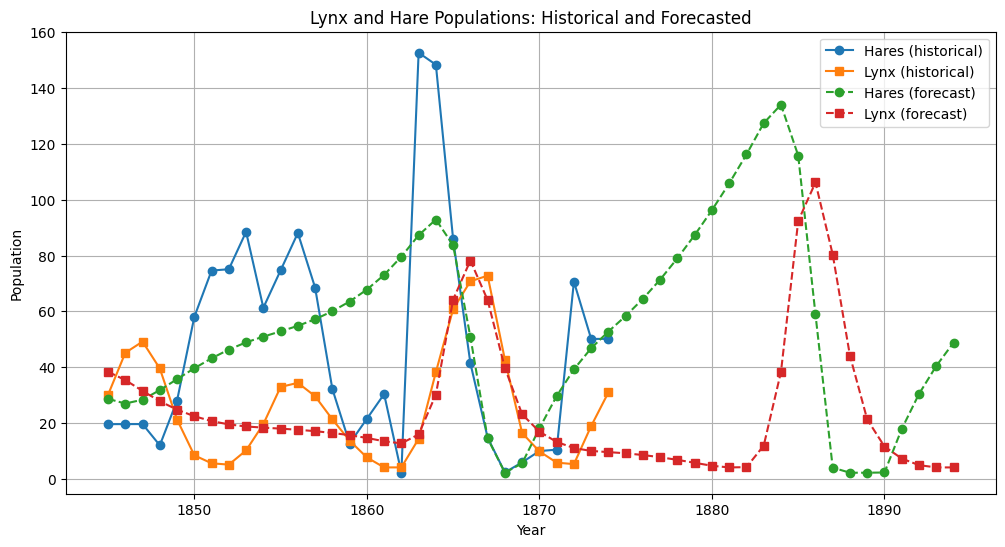

In [25]:
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
import optax
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import random
import matplotlib.pyplot as plt


# Reproducibility
seed = 9
np.random.seed(seed)                 # numpy random seed
random.seed(seed)                    # python random seed
key = jax.random.PRNGKey(seed)       # JAX PRNG key for all JAX operations


# Load and preprocess data
lh_data = jnp.load("LH_data.npy")
years = lh_data[:, 0]
hares = lh_data[:, 1:2]   # column 1
lynx = lh_data[:, 2:3]    # column 2
populations = jnp.hstack([hares, lynx])


# Scale populations to [0,1]
scaler = MinMaxScaler()
pop_scaled = scaler.fit_transform(np.array(populations))


# Time points
t_span = jnp.arange(len(years))


# --- Trainable initial value ---
class TrainableY0(eqx.Module):
    y0: jnp.ndarray

    def __init__(self, initial_value):
        self.y0 = initial_value

trainable_y0 = TrainableY0(jnp.array(pop_scaled[0]))


# Neural ODE function 
class ODEFunc(eqx.Module):
    mlp: eqx.nn.MLP

    def __init__(self, key):
        # Use the provided key for reproducibility
        self.mlp = eqx.nn.MLP(
            in_size=2,
            out_size=2,
            width_size=32,
            depth=2,
            key=key
        )

    def __call__(self, t, y, args=None):
        return self.mlp(y)

ode_func = ODEFunc(key=key)


# Neural ODE solver
def neural_ode(ode_func, trainable_y0, t_span):
    solver = diffrax.Dopri5()
    saveat = diffrax.SaveAt(ts=t_span)
    solution = diffrax.diffeqsolve(
        diffrax.ODETerm(ode_func),
        solver,
        t0=t_span[0],
        t1=t_span[-1],
        dt0=0.1,
        y0=trainable_y0.y0,
        saveat=saveat
    )
    return solution.ys


# Loss
def loss_fn(ode_func, trainable_y0):
    pred = neural_ode(ode_func, trainable_y0, t_span)
    return jnp.mean((pred - pop_scaled) ** 2)


# Optimizer 
optimizer = optax.adam(1e-3)
trainable_modules = (ode_func, trainable_y0)
trainable_params = eqx.filter(trainable_modules, eqx.is_array)
opt_state = optimizer.init(trainable_params)


# Training loop 
num_epochs = 3000
for epoch in range(num_epochs):
    # Compute loss and gradients for the PyTree of modules
    loss, grads = eqx.filter_value_and_grad(
        lambda m: loss_fn(m[0], m[1]), has_aux=False
    )(trainable_modules)

    # Update only the trainable arrays
    updates, opt_state = optimizer.update(grads, opt_state)
    
    # Apply updates to modules
    trainable_modules = eqx.apply_updates(trainable_modules, updates)
    ode_func, trainable_y0 = trainable_modules  # unpack for clarity

    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")


# Forecast next 20 years
future_years = jnp.arange(years[0], 1895)  # 1845-1894
forecast_scaled = neural_ode(ode_func, trainable_y0, future_years)


# Clip negatives to zero
forecast_scaled = jnp.clip(forecast_scaled, 0, None)


# Rescale back to original populations
forecast = scaler.inverse_transform(np.array(forecast_scaled))


# Save predictions
np.save("lh_forecast.npy", forecast)
print("Forecast saved as 'lh_forecast.npy', shape:", forecast.shape)


# Load the forecast
forecast = np.load("lh_forecast.npy")


# Check the shape and contents
print(forecast.shape)
print(forecast)


# Load historical data
lh_data = np.load("LH_data.npy")
years_hist = lh_data[:, 0]
hares_hist = lh_data[:, 1]
lynx_hist = lh_data[:, 2]


# Load forecast
forecast = np.load("lh_forecast.npy")
hares_forecast = forecast[:, 0]
lynx_forecast = forecast[:, 1]
years_forecast = np.arange(1845, 1895)  # 50 years forecast


# Clip negative predicted values to zero
hares_forecast = np.clip(hares_forecast, 0, None)
lynx_forecast = np.clip(lynx_forecast, 0, None)

# Plot historical and forecasted populations
plt.figure(figsize=(12,6))


# Historical data
plt.plot(years_hist, hares_hist, 'o-', label="Hares (historical)")
plt.plot(years_hist, lynx_hist, 's-', label="Lynx (historical)")


# Forecast
plt.plot(years_forecast, hares_forecast, 'o--', label="Hares (forecast)")
plt.plot(years_forecast, lynx_forecast, 's--', label="Lynx (forecast)")


plt.xlabel("Year")
plt.ylabel("Population")
plt.title("Lynx and Hare Populations: Historical and Forecasted")
plt.legend()
plt.grid(True)
plt.show()

**ODE Function Information**:
- Two inputs (hares and lynx)
- Two outputs (rate of change for hares and rate of change for lynx)
- 32 neurons per hidden layer (width size = 32), **2 hidden layers**
- This is a fully connected Neural ODE MLP (multi layer perceptron, each neuron computes a weighted sum of inputs, adds a bias and applies a non linear function) - every neuron in a layer is connected to every neuron in the next.

**Preprocessing**: Loads the Lynx-Hare data and scales the populations to [0,1] so the neural network can train more stably.

**Trainable initial value (trainable_y0)**: Makes the starting population a learnable parameter, allowing the Neural ODE to find the best initial state rather than fixing it.

**Weights and biases initialization**: The MLP inside ODEFunc initializes weights randomly and biases to zero by default, giving the network a starting point for learning the dynamics.

**Neural ODE solver**: Uses diffrax.diffeqsolve with the Dopri5 solver to numerically integrate the learned differential equations over the time points. Dopri5 is preferred here because it provides *accurate solutions with adaptive step sizes while remaining computationally efficient*, making it ideal for non-stiff (stiff means some components change much faster than others) Neural ODEs like the Lynx-Hare system.


**Loss function**: Computes the mean squared error between the predicted populations and the scaled true populations.

**Optimizer**: Uses Adam (optax.adam) to update only the trainable arrays (weights, biases, and initial value) based on computed gradients. Adam is used because it remembers recent gradient trends for each parameter to adjust step sizes adaptively, letting the model converge faster and more stably.

**Training loop**: Iteratively computes gradients, updates trainable parameters, and prints the loss to gradually fit the Neural ODE to the historical data.

**Forecast**: Uses the trained Neural ODE and learned initial value to predict Lynx and Hare populations for future years, then rescales predictions back to the original population values.

**Clip negative values to zero**: so the forecast never predicts negative cases (not possible in real life).

--------------

* **Equinox**: Managed neural network modules and trainable parameters as PyTrees, making JAX gradient updates easy.
* **Diffrax**: Provided an efficient, adaptive ODE solver to integrate the learned dynamics over time.
* **Optax**: Handled optimization with adaptive updates like Adam, letting each parameter converge efficiently.


Epoch 0, Loss: 0.131718
Epoch 100, Loss: 0.127244
Epoch 200, Loss: 0.123918
Epoch 300, Loss: 0.121288
Epoch 400, Loss: 0.119033
Epoch 500, Loss: 0.117005
Epoch 600, Loss: 0.115132
Epoch 700, Loss: 0.113369
Epoch 800, Loss: 0.111693
Epoch 900, Loss: 0.110092
Epoch 1000, Loss: 0.108560
Epoch 1100, Loss: 0.107094
Epoch 1200, Loss: 0.105691
Epoch 1300, Loss: 0.104350
Epoch 1400, Loss: 0.103071
Forecast saved as 'covid_forecast.npy', shape: (100, 1)
(100, 1)
[[ 693.19147]
 [ 715.9826 ]
 [ 738.5231 ]
 [ 760.81586]
 [ 782.86383]
 [ 804.66895]
 [ 826.2344 ]
 [ 847.56384]
 [ 868.65875]
 [ 889.52246]
 [ 910.1551 ]
 [ 930.5619 ]
 [ 950.7445 ]
 [ 970.70544]
 [ 990.44727]
 [1009.97205]
 [1029.2819 ]
 [1048.3798 ]
 [1067.2682 ]
 [1085.9479 ]
 [1104.4231 ]
 [1122.6952 ]
 [1140.7665 ]
 [1158.639  ]
 [1176.3156 ]
 [1193.7972 ]
 [1211.0872 ]
 [1228.1874 ]
 [1245.1001 ]
 [1261.8252 ]
 [1278.3683 ]
 [1294.7286 ]
 [1310.9093 ]
 [1326.9127 ]
 [1342.7396 ]
 [1358.393  ]
 [1373.8748 ]
 [1389.1864 ]
 [1404.329

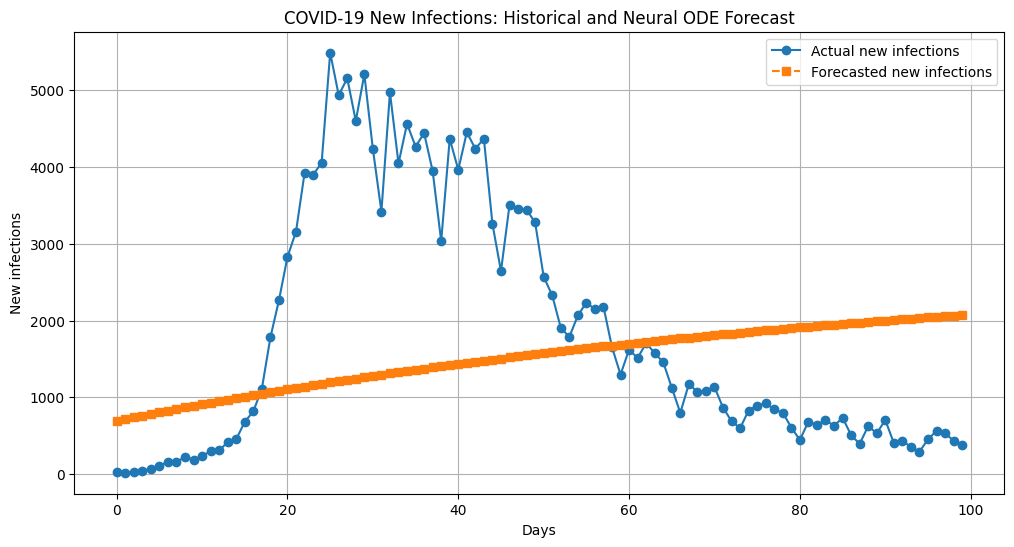

In [57]:
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
import optax
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import random
import matplotlib.pyplot as plt


# Reproducibility
seed = 15
np.random.seed(seed)
random.seed(seed)
key = jax.random.PRNGKey(seed)


# Load and preprocess data
covid_data = np.load("covid_data.npy")
t_days = covid_data[:, 0:1]        # days
cases = covid_data[:, 1:2]         # new infections


# Scale cases and time to [0,1] for stable training
scaler_cases = MinMaxScaler()
cases_scaled = scaler_cases.fit_transform(cases)

scaler_time = MinMaxScaler()
t_scaled = scaler_time.fit_transform(t_days)


# Augment initial state with time
y0_aug = jnp.array([cases_scaled[0, 0], t_scaled[0, 0]])


# --- Trainable initial value ---
class TrainableY0(eqx.Module):
    y0: jnp.ndarray
    def __init__(self, initial_value):
        self.y0 = initial_value

trainable_y0 = TrainableY0(y0_aug)


# Neural ODE function
class ODEFunc(eqx.Module):
    mlp: eqx.nn.MLP
    def __init__(self, key):
        self.mlp = eqx.nn.MLP(
            in_size=2,   # infection + scaled time
            out_size=1,  # rate of change of infection
            width_size=8,
            depth=1,
            key=key
        )
    def __call__(self, t, y, args=None):
        # y = [infection, time_scaled]
        return self.mlp(y)

ode_func = ODEFunc(key=key)


# Neural ODE solver
def neural_ode(ode_func, trainable_y0, t_scaled):
    solver = diffrax.Dopri5()
    saveat = diffrax.SaveAt(ts=t_scaled.flatten())
    solution = diffrax.diffeqsolve(
        diffrax.ODETerm(ode_func),
        solver,
        t0=t_scaled[0,0],
        t1=t_scaled[-1,0],
        dt0=0.001,
        y0=trainable_y0.y0,
        saveat=saveat
    )
    return solution.ys[:, 0:1]  # only return infection


# Loss function
def loss_fn(ode_func, trainable_y0):
    pred = neural_ode(ode_func, trainable_y0, t_scaled)
    return jnp.mean((pred - cases_scaled) ** 2)


# Optimizer
optimizer = optax.adam(1e-4)
trainable_modules = (ode_func, trainable_y0)
trainable_params = eqx.filter(trainable_modules, eqx.is_array)
opt_state = optimizer.init(trainable_params)


# Training loop
num_epochs = 1500
for epoch in range(num_epochs):
    loss, grads = eqx.filter_value_and_grad(
        lambda m: loss_fn(m[0], m[1]), has_aux=False
    )(trainable_modules)

    updates, opt_state = optimizer.update(grads, opt_state)
    trainable_modules = eqx.apply_updates(trainable_modules, updates)
    ode_func, trainable_y0 = trainable_modules

    if epoch % 100 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.6f}")


# Predict infections
forecast_scaled = neural_ode(ode_func, trainable_y0, t_scaled)


# Clip negatives to zero
forecast_scaled = jnp.clip(forecast_scaled, 0, None)


# Rescale back to original number of infections
forecast = scaler_cases.inverse_transform(np.array(forecast_scaled))


# Save predictions
np.save("covid_forecast.npy", forecast)
print("Forecast saved as 'covid_forecast.npy', shape:", forecast.shape)

# Load the forecast
forecast = np.load("covid_forecast.npy")

# Check the shape and contents
print(forecast.shape)
print(forecast)

# Plot historical and forecast
plt.figure(figsize=(12,6))
plt.plot(t_days, cases, 'o-', label="Actual new infections")
plt.plot(t_days, forecast, 's--', label="Forecasted new infections")
plt.xlabel("Days")
plt.ylabel("New infections")
plt.title("COVID-19 New Infections: Historical and Neural ODE Forecast")
plt.legend()
plt.grid(True)
plt.show()

**COVID Neural ODE Model Summary**

- **Epochs:** Reduced from 3000 to 1500 to avoid overfitting and exploding predictions.  
- **Time input:** Scaled time added as an input feature so the model can better account for the temporal dynamics.  
- **Learning rate:** Reduced in Adam from 1e-3 to 1e-4 to stabilize training.  
- **Network architecture:** Reduced depth from 2 to 1 and neurons from 32 to 8 to prevent the model from overfitting the tiny dataset.  
- **Observations:** Despite these adjustments, the Neural ODE struggles with this COVID-19 dataset because the dynamics are highly discrete, noisy, and small in magnitude, which violates the smooth continuous assumptions Neural ODEs rely on. The model tends to predict straight lines or average trajectories rather than capturing peaks accurately.


### Diffrax Formuating Considerations

Our code and the reviewed professional diffrax code share a very similar structure and style, which is **great** because it follows best practices for clarity and modularity:

- Both scripts **import necessary libraries at the top** and set up reproducibility and preprocessing before defining the core computation.
- The **Neural ODE / ODE solver functions** are clearly separated from the training loop or prediction steps, making it easy to read and maintain.
- Both use **JAX + JIT compilation** where appropriate (`@jax.jit` in the professional code, `eqx` + `jax` in yours), showing our awareness of performance optimization.
- The **ODE function is wrapped as a modular callable**
- The reviewed professional code uses `CubicInterpolation` and `backward_hermite_coefficients` to handle interpolation neatly; in your code, you use `diffrax.diffeqsolve` which is equivalent in style and modularity.
- Both examples **clearly separate the solver, the initial condition, and the evaluation**, which makes it easy to swap out solvers or modify initial values.

In short, our formatting mirrors the professional style: clear sections, modular functions, concise solver definitions, and explicit handling of initial conditions and outputs.